# Previsione del prezzo di un immobile — California Housing Dataset

#### Studente: Giannini Matteo

# 1. Introduzione del problema

- Il problema che si vuole affrontare:
  
  Previsione del prezzo mediano di un immobile a partire dalle sue caratteristiche (posizione geografica, numero di stanze ecc.).

- Il tipo di task:
  
  Si tratta di un task di Regressione supervisionata: la variabile target può assumere qualsiasi valore nell'intervallo (prezzo mediano delle case).

- Obiettivo:
  
  Stimare il prezzo medio delle case In California a partire dai dati del California Housing Dataset. Il modello deve imparare le relazioni tra variabili come reddito medio, numero medio di stanze, posizione geografica, per fornire una stima il più accurata possibile del prezzo delle case in una determinata area.

- Interesse pratico o applicativo del problema:
  
  La stima del valore immobiliare è un problema reale e utile in vari contesti: agenzie immobiliari, banche, investitori, privati, e aiuta nella decisione di acquisti, vendite o investimenti.

# 2. Descrizione del Dataset

- Origine del Dataset: https://www.kaggle.com/datasets/camnugent/california-housing-prices
  
- Descrizione delle variabili:
  - `longitude`: longitudine del blocco residenziale
  - `latitude`: latitudine del blocco residenziale
  - `housing_median_age`: età mediana delle residenziale
  - `total_rooms`: numero totale di stanze  
  - `total_bedrooms`: numero totale di camere da letto
  - `population`: totale abitanti del blocco residenziale
  - `households`: totale famiglie del blocco residenziale
  - `median_income`: reddito mediano delle famiglie 
  - `ocean_proximity`: distanza dal mare (variabile categorica)
  
- Variabile target:
  `median_house_value` -> prezzo mediano delle case in un blocco residenziale

- Dimensione del dataset:
  20640 righe, 10 colonne

- Eventuali note sul contesto dei dati:
  - `total_bedrooms` contiene alcuni valori mancanti.
  - `ocean_proximity` è l'unica variabile non numerica e richiede encoding.


# 3. Lettura e preparazione dei dati

### Import librerie

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# (altre librerie aggiunte successivamente sotto)

### Import del Dataset

In [2]:
df = pd.read_csv("housing.csv")

Visualizzazione delle prime 5 righe

In [3]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### Dimensione del Dataset

In [4]:
df.shape

(20640, 10)

### Estrazione dei nomi delle colonne e il tipo di dato

Notare che la colonna `total_bedrooms` contiene 207 valori mancanti che verranno gestiti prima dell'addestramento.

L'unica variabile categorica (object) è `ocean_proximity`, che richiederà una fase di encoding.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


### Verifica di valori mancanti

In [6]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

### Trasformazioni iniziali

Elimino le righe nulle della colonna `total_bedrooms` e verifico che non ci siano più valori nulli. 

In [8]:
df = df.dropna()

df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

### Encoding

Converto la colonna categorica `ocean_proximity` in colonna numerica, così che ogni categoria diventa una colonna con valori 0 e 1.

In [ ]:
df = pd.get_dummies(df, columns=["ocean_proximity"])

Mostro le colonne risultanti

In [14]:
df.columns.tolist()

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'median_house_value',
 'ocean_proximity_<1H OCEAN',
 'ocean_proximity_INLAND',
 'ocean_proximity_ISLAND',
 'ocean_proximity_NEAR BAY',
 'ocean_proximity_NEAR OCEAN']

# 4. Visualizzazione ed EDA

In questa sezione esploro il Dataset per capire meglio la struttura dei dati prima di costruire i modelli.

### Statistiche descrittive

`total_rooms` max è 39.320 e `population` max è 35.682 -> valori molto alti rispetto alla media (possibili outlier da analizzare).

In [15]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000
mean,-119.570689,35.633221,28.633094,2636.504233,537.870553,1424.946949,499.433465,3.871162,206864.413155
std,2.003578,2.136348,12.591805,2185.269567,421.385070,1133.208490,382.299226,1.899291,115435.667099
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1450.000000,296.000000,787.000000,280.000000,2.563700,119500.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.536500,179700.000000
75%,-118.010000,37.720000,37.000000,3143.000000,647.000000,1722.000000,604.000000,4.744000,264700.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


### Distribuzioni delle variabili
Capire se sono presenti anomalie, valori estremi o variabili che possono disturbare il training.

Si può osservare che `median_house_value` ha un picco a 500.001, che `total_rooms`, `population`, `total_bedrooms`, `households` hanno code lunghe (possibili outlier).

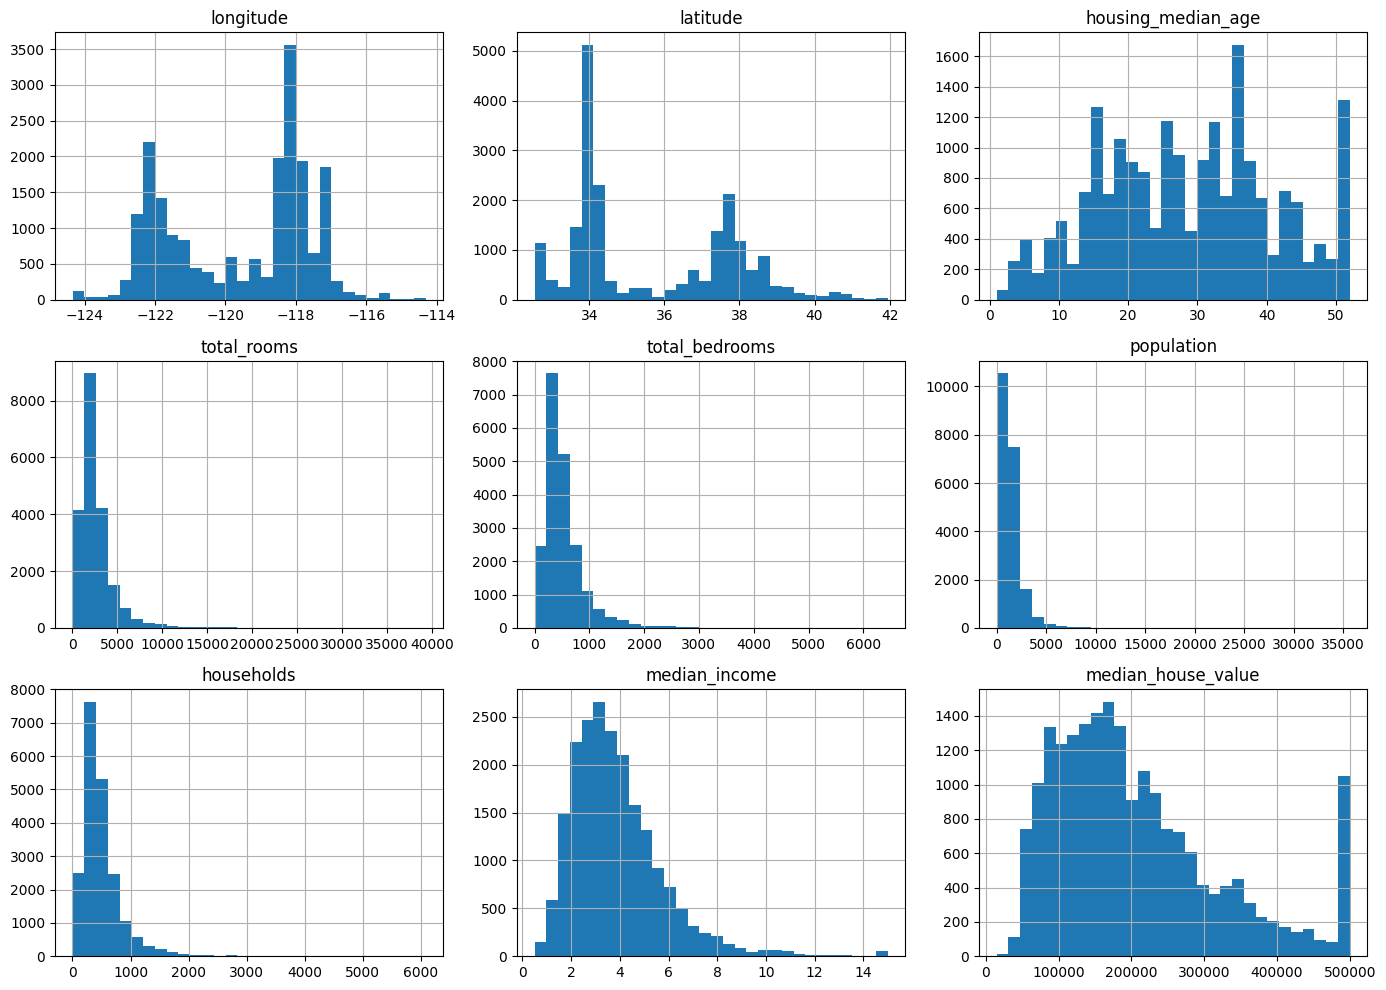

In [22]:
df.hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

### Relazioni tra feature

Relazione tra `median_income` e `median_house_value`.

Al crescere del reddito, il prezzo tende ad aumentare.

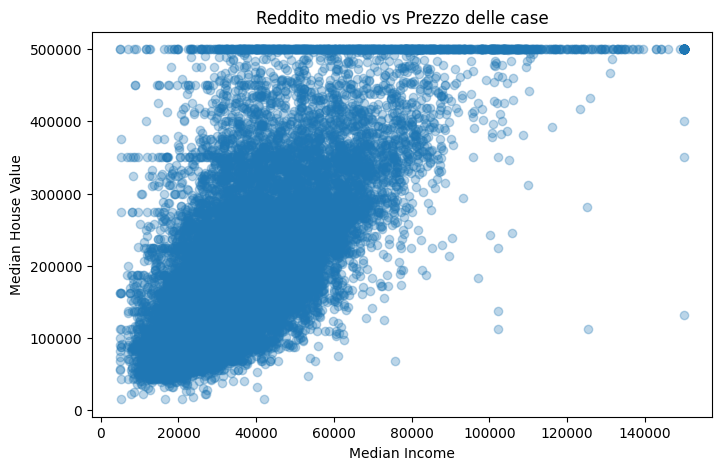

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df["median_income"] * 10000, df["median_house_value"], alpha=0.3)
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Reddito medio vs Prezzo delle case")
plt.show()

### Distribuzione geografica dei prezzi

Visualizzo la posizione geografica del blocco residenziale in base al prezzo mediano.

Questo permette di capire se la zona geografica influenza il prezzo delle case.

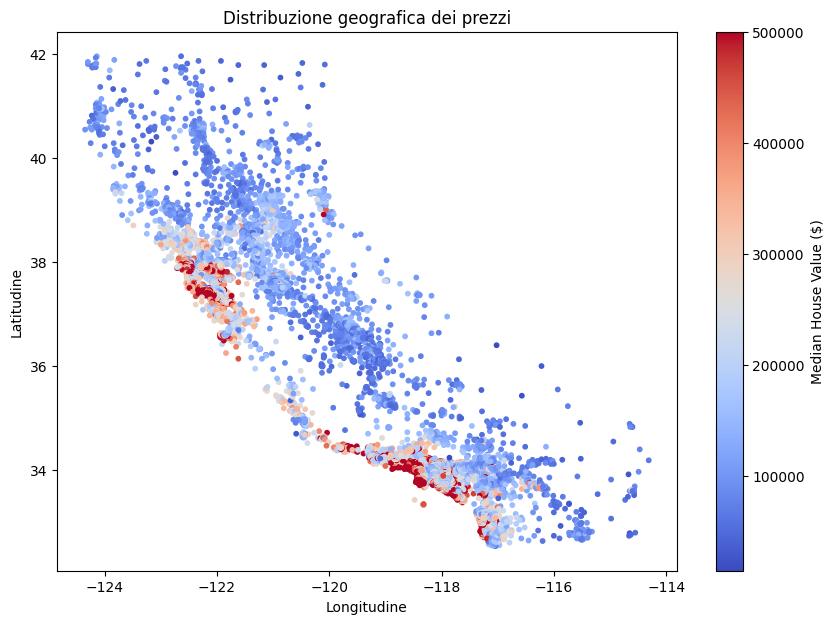

In [50]:
plt.figure(figsize=(10, 7))
plt.scatter(df["longitude"], df["latitude"], 
            c=df["median_house_value"], cmap="coolwarm", alpha=1, s=10)
plt.colorbar(label="Median House Value ($)")
plt.xlabel("Longitudine")
plt.ylabel("Latitudine")
plt.title("Distribuzione geografica dei prezzi")
plt.show()

Le zone con prezzi più alti sono concentrate sulla costa ovest della California.

### Eventuali correlazioni

Analizzo la correlazione tra tutte le variabili numeriche per capire quali feature sono più legate al prezzo delle case.

In [ ]:
#seleziono le colonne numeriche principali
colonne = ["median_income", "total_rooms", "housing_median_age", 
           "population", "households", "median_house_value"]

# matrice di correlazione
print(df[colonne].corr())

                    median_income  total_rooms  housing_median_age  \
median_income            1.000000     0.197882           -0.118278   
total_rooms              0.197882     1.000000           -0.360628   
housing_median_age      -0.118278    -0.360628            1.000000   
population               0.005087     0.857281           -0.295787   
households               0.013434     0.918992           -0.302768   
median_house_value       0.688355     0.133294            0.106432   

                    population  households  median_house_value  
median_income         0.005087    0.013434            0.688355  
total_rooms           0.857281    0.918992            0.133294  
housing_median_age   -0.295787   -0.302768            0.106432  
population            1.000000    0.907186           -0.025300  
households            0.907186    1.000000            0.064894  
median_house_value   -0.025300    0.064894            1.000000  


`median_income` → `median_house_value`: 0.69 — correlazione positiva forte, quindi conferma che il reddito è la feature più importante.

`housing_median_age` → `median_house_value`: 0.11 — correlazione debole, l'età della casa conta poco sul prezzo.

### Osservazioni emerse dall'analisi esplorativa

- `median_income` è la variabile più correlata al prezzo (0.69) e sarà probabilmente la feature più importante per i modelli.
- La posizione geografica influenza il prezzo: le zone costiere mostrano valori più alti.
-  `total_rooms`, `households` e `population` sono molto correlate tra loro (>0.90) ma poco correlate al prezzo.
-  `housing_median_age` ha una correlazione quasi nulla con il prezzo (0.11), quindi abitazioni vecchie hanno poco valore.
-  `median_house_value` presenta un troncamento a 500.001$ che rappresenta un limite del dataset.



# 5. Outlier detection / preprocessing

In questa sezione analizzo i valori anomali presenti nel Dataset, questo perchè un outlier può distorcere le previsioni.

Uso degli outlier puntuali perchè il Dataset è tabellare: non esiste una sequenza temporale o sequenziale tra i dati.

Applico 3 tecniche su tutte le feature numeriche e alla fine confronto i risultati:
- Z-score: identifica outlier in base alla distanza dalla media, in termini di deviazione standard.
- MAD (Median Absolute Deviation): misura di quanto i dati si discostano dalla madiana. Più robusto di Z-score.
- Isolation Forest: trova outlier facendo tagli casuali sui dati. Un punto è anomalo se è facile da separare dal resto dei dati.

### Valori anomali, improbabili, critici

Dall'analisi della sezione 4 ho osservato che alcune variabili presentano valori estremi:

- `total_rooms`: media 2.636, massimo 39.320
- `total_bedrooms`: media 537, massimo 6.445
- `population`: media 1.424, massimo 35.682
- `households`: media 499, massimo 6.082

Questi valori massimi sono molto lontani dalla media e rappresentano casi improbabili o critici che potrebbero distorcere le previsioni del modello.

In [ ]:
colonne_sospette = ["total_rooms", "total_bedrooms", "population", "households", "median_house_value"]
df[colonne_sospette].describe().loc[["mean", "max"]]

,total_rooms,total_bedrooms,population,households,median_house_value
mean,2636.504233,537.870553,1424.946949,499.433465,206864.413155
max,39320.000000,6445.000000,35682.000000,6082.000000,500001.000000


### Tecniche di outlier detection

#### Calcolo lo z-score per ogni colonna numerica

In [ ]:
from scipy import stats

#seleziono solo le colonne numeriche originali (escludo quelle create con get_dummies)
colonne_num = ["longitude", "latitude", "housing_median_age", "total_rooms", 
               "total_bedrooms", "population", "households", 
               "median_income", "median_house_value"]

#calcolo lo z-score per ogni colonna
z_scores = np.abs(stats.zscore(df[colonne_num]))

#segno come outlier le righe che hanno almeno una colonna con |z| > 3
outlier_zscore = (z_scores > 3).any(axis=1)

print("Outlier trovati con Z-score:", outlier_zscore.sum())

# 884 -> 4.3%

Outlier trovati con Z-score: 884


#### Calcolo il MAD - Median Absolute Deviation

In [ ]:
def mad(arr):
    med = np.median(arr)
    return np.median(np.abs(arr - med))

# creo una serie inizialmente a False, che verrà poi aggiornata a True per le righe in cui viene trovato almeno un outlier
outlier_mad = pd.Series(False, index=df.index)

#calcolo il MAD per ogni colonna numerica e segno come outlier i valori con modified z-score > 3.5
for col in colonne_num:
    med = np.median(df[col])
    mad_val = mad(df[col])
    modified_z = 0.6745 * (df[col] - med) / mad_val
    outlier_mad = outlier_mad | (modified_z.abs() > 3.5)

print("Outlier trovati con MAD:", outlier_mad.sum())

Outlier trovati con MAD: 2030


#### Calcolo Isolation Forest

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler() #crea uno scaler: serve a standardizzare i dati (media 0, deviazione 1).
X_scaled = scaler.fit_transform(df[colonne_num]) #standardizza le variabili numeriche

#Creo il modello Isolation Forest
# contamination = percentuale stimata di outlier nel dataset. Scelto in base al risultato di Z-index (4.3%) -> arrotondato a 5
iso = IsolationForest(contamination=0.05, random_state=42)
pred_iso = iso.fit_predict(X_scaled)

#converto: -1 (outlier) → True, 1 (normale) → False
outlier_iso = pd.Series(pred_iso == -1, index=df.index)

print("Outlier trovati con Isolation Forest:", outlier_iso.sum())

Outlier trovati con Isolation Forest: 1022


### Motivazione delle scelte --> Confronto dei metodi

Lo Z-index è il più 'cauto', perchè usa la media, quindi è più influenzata dai valori estremi e trova meno outlier. 

Il MAD è il più sensibile perchè usa la mediana ed è più reattivo alle distribuzioni asimmetriche.

Scelgo però di rimuovere gli outlier identificati da ISOLATION FOREST, perchè considera le relazioni tra tutte le variabili contemporaneamente, non solo i valori estremi singoli come Z-index e MAD.

Un immobile può avere un numero di stanze normale e una popolazione normale, ma la combinazione delle due insieme ad altre feature può essere anomala, e Isolation Forest lo rileva. Quindi è più adatto al nostro caso.

### Strategie di pulizia --> rimuovo le righe identificate come outlier da Isolation Forest

In [62]:
df_clean = df[~outlier_iso]

print("Righe prima:", len(df))
print("Righe dopo:", len(df_clean))

Righe prima: 20433
Righe dopo: 19411


### Preprocessing 

Prima di addestrare i modelli, divido il dataset in feature (X) e target (y). 

Lo scaling verrà applicato nella sezione 6, dopo la divisione in train e test, per evitare il data leakage.

In [ ]:
#definisco X (feature) e y (target -> da prevedere)
X = df_clean.drop(columns=["median_house_value"])
y = df_clean["median_house_value"]

# 6. Implementazione di uno o più modelli

In questa sezione addestriamo e confrontiamo tre modelli di Machine Learning e per ognuno calcoliamo i pesi. Infine faccio la Cross-validation sul modello migliore.

- **Linear Regression** (modello lineare): Assume una relazione lineare tra le feature e il prezzo.

- **Random Forest Regressor** (modello basato su alberi): più robusto, non è sensibile alle differenze di scala tra le feature e gestisce bene le relazioni non lineari.

- **MLP Regressor** (rete neurale): capace di catturare relazioni complesse e non lineari tra le feature, ma richiede più dati e scaling.

Prima di addestrare i modelli, divido il dataset in Train set (80%) e Test set (20%).

Lo scaling viene applicato dopo lo split per evitare il data leakage: il fit dello StandardScaler viene fatto solo sui dati di Train, poi usato per trasformare sia Train che Test.

### Split Train/Test

In [78]:
from sklearn.model_selection import train_test_split

#divido il dataset in train (80%) e test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (15528, 13)
Test: (3883, 13)


### Scaling

Per evitare il data leakage, lo StandardScaler viene addestrato solo sui dati di training e poi applicato sia al train che al test.

In [ ]:
from sklearn.preprocessing import StandardScaler

#inizializzo lo scaler
scaler = StandardScaler()

#Fit solo sul train, transform su entrambi
X_train_scaled = scaler.fit_transform(X_train) #le 15.528 righe di training con tutte le feature scalate — il modello ci si allena sopra
X_test_scaled = scaler.transform(X_test) #le 3.883 righe di test con le stesse feature scalate — il modello ci fa le previsioni per essere valutato

### Linear Regression

Primo modello, usato come baseline. Assume una relazione lineare tra le feature e il prezzo.

Lo alleniamo sui dati di training e valutiamo le previsioni sul test set usando tre metriche:
- **MAE** (Mean Absolute Error): errore medio assoluto in dollari.
- **RMSE** (Root Mean Squared Error): penalizza di più gli errori grandi
- **R²**: quanto il modello spiega la varianza del target (1 = perfetto, 0 = non spiega nulla)
  
Lo scelgo come punto di partenza per capire se un approccio semplice è già sufficiente o se serve un modello più complesso per prevedere il prezzo.

In [80]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

lr = LinearRegression()

#alleno il modello sui dati di training
lr.fit(X_train_scaled, y_train)

#Faccio le previsioni sui dati di test
y_pred_lr = lr.predict(X_test_scaled)

#calcolo le metriche
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = mean_squared_error(y_test, y_pred_lr) ** 0.5
r2_lr = lr.score(X_test_scaled, y_test)

print("MAE:", round(mae_lr, 2))
print("RMSE:", round(rmse_lr, 2))
print("R²:", round(r2_lr, 4))

MAE: 48310.73
RMSE: 65765.86
R²: 0.6588


/Users/matteo/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/matteo/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/matteo/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/matteo/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/matteo/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/matteo/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: Runti

In media il modello sbaglia di ~48.000$ sul prezzo e spiega circa il 66% delle varianze del prezzo delle case.

Vediamo se con i prossimi modelli c'è margine di miglioramento.

### Calcolo dei pesi --> Linear Regression

Mostro quanto ogni feature influenza il prezzo dal modello.

valore positivo: feature aumenta il prezzo | valore negativo: feature diminuisce il prezzo

In [90]:
#associa i coefficienti del modello alle colonne originali
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficiente': lr.coef_
})

# ordinati dal più influente al meno influente
coef_df = coef_df.sort_values('Coefficiente', ascending=False)
print(coef_df)

                       Feature  Coefficiente
7                median_income  75761.156489
4               total_bedrooms  51342.715936
6                   households  16395.428408
2           housing_median_age  14903.968635
8    ocean_proximity_<1H OCEAN   5830.750024
12  ocean_proximity_NEAR OCEAN   5517.012037
11    ocean_proximity_NEAR BAY    868.884539
10      ocean_proximity_ISLAND    792.974185
9       ocean_proximity_INLAND -10803.601633
3                  total_rooms -24215.007606
5                   population -39773.909928
0                    longitude -51015.162525
1                     latitude -51547.084856


- `median_income` conferma quanto visto nell'Eda: il reddito è la feature più importante.
- `longitude` e latitude hanno coefficienti negativi alti — la posizione influenza molto il prezzo.
- `ocean_proximity_INLAND` è negativa — case lontane dal mare costano meno
- `total_rooms` negativo è controintuitivo — più stanze dovrebbero aumentare il prezzo, ma qui è negativo probabilmente perché è correlato con population e households. Quando 2 o più feature sono molto correlate, i coefficienti diventano instabili e poco interpretabili, e di conseguenza il modello assegna pesi instabili.

Vediamo se Random Forest e MLP possono fare meglio.


### Random Forest Regressor

Secondo modello basato su alberi di decisione.

Costruisco 100 alberi diversi e faccio la media delle loro previsioni.

Lo scelgo perchè dovrebbe gestire bene le relazioni non lineari tra le feature; a differenza della Linear Regression non assume che il prezzo cresca in modo proporzionale alle feature, ma impara pattern più complessi dai dati (ci si aspetta ad esempio che capisca che in certe zone il reddito conta di più, o che una combinazione specifica di stanze e posizione porta a prezzi diversi).

In [81]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)

rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)

#Calcolo le metriche
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf) ** 0.5
r2_rf = rf.score(X_test_scaled, y_test)

print("MAE:", round(mae_rf, 2))
print("RMSE:", round(rmse_rf, 2))
print("R²:", round(r2_rf, 4))

MAE: 31785.11
RMSE: 48189.53
R²: 0.8168


Random Forest migliora rispetto alla Linear Regression: il MAE scende da 48.310$ a 31.785$ e R² sale da 0.66 a 0.82 confermando che il prezzo delle case non segue una relazione lineare semplice.

### Calcolo dei pesi --> Random Forest

Random Forest assegna a ogni feature un punteggio di importanza che indica quanto quella feature ha contribuito alle previsioni del modello.

In [91]:
#associa le importances alle colonne originali
importances_df = pd.DataFrame({
    'Feature': X.columns,
    'Importanza': rf.feature_importances_
})

# ordine dalla più importante alla meno importante
importances_df = importances_df.sort_values('Importanza', ascending=False)
print(importances_df)

                       Feature  Importanza
7                median_income    0.462596
9       ocean_proximity_INLAND    0.144084
0                    longitude    0.111423
1                     latitude    0.108880
2           housing_median_age    0.057324
5                   population    0.034656
3                  total_rooms    0.025392
4               total_bedrooms    0.024039
6                   households    0.019722
12  ocean_proximity_NEAR OCEAN    0.007770
8    ocean_proximity_<1H OCEAN    0.003377
11    ocean_proximity_NEAR BAY    0.000734
10      ocean_proximity_ISLAND    0.000003


- median_income: quasi la metà delle decisioni degli alberi si basa sul reddito ed è coerente con l'EDA.
- longitude e latitude: posizione geografica conta molto.
- ocean_proximity_ISLAND: quasi zero, pochissime case in quella categoria.

###  MLP Regressor (Multi-Layer Perceptron)

Terzo modello: proviamo a separare i dati con una linea curva usando una rete neurale con strati nascosti.

In [89]:
from sklearn.neural_network import MLPRegressor

#Inizializzo la rete neurale con 2 strati nascosti da 100 neuroni ciascuno
mlp = MLPRegressor(hidden_layer_sizes=(100, 100), activation='relu', solver='adam', max_iter=2000, random_state=42)

mlp.fit(X_train_scaled, y_train)

y_pred_mlp = mlp.predict(X_test_scaled)

#calcolo metriche
mae_mlp = mean_absolute_error(y_test, y_pred_mlp)
rmse_mlp = mean_squared_error(y_test, y_pred_mlp) ** 0.5
r2_mlp = mlp.score(X_test_scaled, y_test)

print("MAE:", round(mae_mlp, 2))
print("RMSE:", round(rmse_mlp, 2))
print("R²:", round(r2_mlp, 4))

/Users/matteo/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/matteo/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/matteo/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


MAE: 36003.72
RMSE: 53277.3
R²: 0.7761


/Users/matteo/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/matteo/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/matteo/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/matteo/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/matteo/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/matteo/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  re

Con MLP si ottiene R²=0.776, risultato simile a Random Forest (0.816). MAE più alto. C'è possibilità di avere ulteriore miglioramento aumentando le iterazioni.

Con MLP non possiamo calcolare i pesi perché ogni feature passa attraverso tanti neuroni in sequenza: il contributo delle feature al prezzo è il risultato di molte moltiplicazioni e somme diverse, e alla fine non sai più quanto ha contribuito il reddito originale.

### Osservazioni

Random Forest ottiene il MAE più basso e l'R² più alto --> modello migliore.

Linear Regression spiega solo il 66% della varianza del prezzo, mentre Random Forest arriva a 0.82, e questo dimostra che c'è una componente non lineare che la regressione lineare non riesce a catturare.

MLP potrebbe migliorare con più iterazioni.

### Cross-validation --> Random Forest

Applico la Cross-validation sulla Random forest visto che ha dato i risultati migliori, per verificare che i risultati siano stabili e non dipendano dal singolo split train/test.

In [93]:
from sklearn.model_selection import cross_val_score
import numpy as np

# 5 test di validazione
cv_scores = cross_val_score(rf, X_train_scaled, y_train, cv=5, scoring='r2')

print("R² per ogni fold:", cv_scores.round(4))
print("Media R²:", round(cv_scores.mean(), 4))
print("Deviazione standard:", round(cv_scores.std(), 4))

R² per ogni fold: [0.7978 0.8064 0.8274 0.7946 0.8119]
Media R²: 0.8076
Deviazione standard: 0.0116


Media R² 0.808 — coerente con il 0.816 ottenuto sul test set.

Deviazione standard 0.011 — molto bassa, il modello è stabile sui fold.

Calcolo R² sul training set per confrontarlo con quello sul test set e verificare overfitting.

In [99]:
r2_train_rf = rf.score(X_train_scaled, y_train)
print("R² Train:", round(r2_train_rf, 4))
print("R² Test:", round(r2_rf, 4))

R² Train: 0.9744
R² Test: 0.8168


Il modello si adatta meglio ai dati di training che a quelli nuovi (tende a overfittare sul training).

# 7. Valutazione e confronto dei risultati

In questa sezione confronto le prestazioni dei tre modelli usando le metriche MAE, RMSE e R².

Valuto quanto il modello sbaglia in media sul prezzo (MAE, RMSE) e quanto spiega la varianza del target (R²).

Nella sezione 6 ho già calcolato le metriche, qui le confronto con i grafici, quindi le metto insieme per vedere chi vince.

### Confronto MAE tra modelli

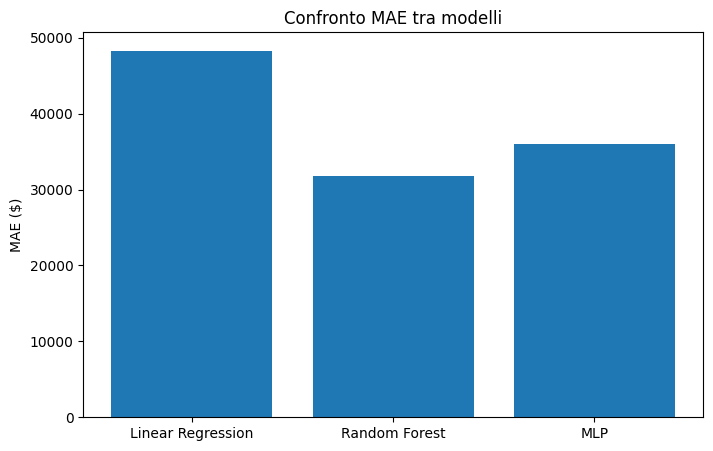

In [94]:
modelli = ['Linear Regression', 'Random Forest', 'MLP']
mae_values = [mae_lr, mae_rf, mae_mlp]

plt.figure(figsize=(8, 5))
plt.bar(modelli, mae_values)
plt.title('Confronto MAE tra modelli')
plt.ylabel('MAE ($)')
plt.show()

Random Forest è il modello migliore sul MAE.

### Confronto R² tra modelli

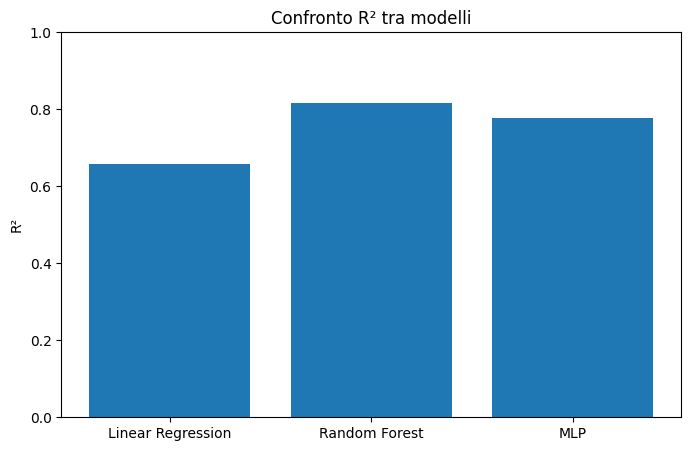

In [ ]:
r2_values = [r2_lr, r2_rf, r2_mlp]

plt.figure(figsize=(8, 5))
plt.bar(modelli, r2_values)
plt.title('Confronto R² tra modelli')
plt.ylabel('R²')
plt.ylim(0, 1)
plt.show()

Random Forest R²=0.82 --> il modello riesce a spiegare l'82% della variabilità nei prezzi delle case. 

È il modello migliore dei tre perché gestisce bene le relazioni non lineari tra le feature. Usa tanti alberi decisionali insieme (ensemble), quindi è più robusto rispetto a un singolo modello lineare e non è sensibile agli outlier come la regressione lineare.

### Valori predetti vs valori reali (Random Forest)

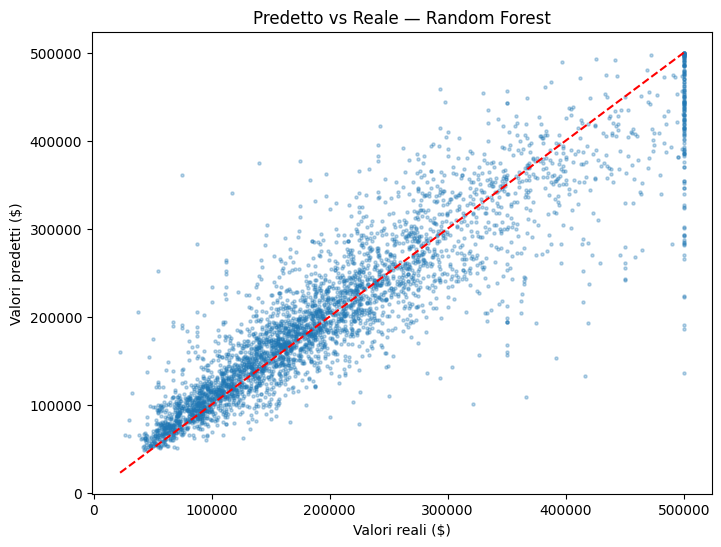

In [96]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.3, s=5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Valori reali ($)")
plt.ylabel("Valori predetti ($)")
plt.title("Predetto vs Reale — Random Forest")
plt.show()

I punti seguono bene la diagonale rossa --> il modello predice correttamente nella maggior parte dei casi.

Più ci si allontana dalla diagonale, più l'errore è grande 

### Tabella riassuntiva delle metriche

In [97]:
risultati = pd.DataFrame({
    'Modello': ['Linear Regression', 'Random Forest', 'MLP'],
    'MAE ($)': [round(mae_lr, 2), round(mae_rf, 2), round(mae_mlp, 2)],
    'RMSE ($)': [round(rmse_lr, 2), round(rmse_rf, 2), round(rmse_mlp, 2)],
    'R²': [round(r2_lr, 4), round(r2_rf, 4), round(r2_mlp, 4)]
})

risultati

,Modello,MAE ($),RMSE ($),R²
0,Linear Regression,48310.73,65765.86,0.6588
1,Random Forest,31785.11,48189.53,0.8168
2,MLP,36003.72,53277.30,0.7761


### Osservazioni

Random Forest è il modello migliore su tutte le metriche: MAE più basso (31.785$), RMSE più basso (48.189$) e R² più alto (0.82). Riesce a catturare le relazioni non lineari tra le feature meglio degli altri due modelli.

MLP si colloca a metà strada (R²=0.78) ma richiede più iterazioni per convergere correttamente.

La cross-validation conferma che il modello generalizza in modo stabile. Si osserva un leggero overfitting (R² Train=0.97 vs Test=0.82)

# 8. Conclusioni finali

### Problema affrontato

L'obiettivo del progetto era sviluppare un sistema di regressione in grado di stimare il prezzo mediano delle abitazioni in California a partire da diverse caratteristiche del California Housing Dataset.

### Metodo seguito

Ho iniziato con una fase di analisi esplorativa (EDA), durante la quale ho analizzato le distribuzioni delle variabili, le correlazioni tra le feature e la distribuzione geografica dei prezzi.

Successivamente ho identificato e rimossi gli outlier mediante tre tecniche: 
- Z-score
- MAD 
- Isolation Forest. 

Ho scelto Isolation Forest perché considera le relazioni tra tutte le variabili contemporaneamente.

Infine ho addestrato tre modelli: 
- Linear Regression 
- Random Forest Regressor 
- MLP Regressor. 

Lo StandardScaler è stato applicato dopo la divisione train/test per evitare il data leakage.

### Risultati principali

Random Forest ha ottenuto i risultati migliori su tutte le metriche: 
- MAE=31.785$ 
- RMSE=48.189$ 
- R²=0.82. 

Linear Regression ha ottenuto 
- R²=0.66 
- MLP R²=0.78.

La cross-validation sul modello migliore (R² medio=0.81, std=0.01) conferma che Random Forest generalizza in modo stabile su dati nuovi.

### Conclusioni più importanti

Si può confermare che il reddito medio (median_income) è la feature più correlata al prezzo (correlazione 0.69) e la più importante per Random Forest (importanza 0.46). Anche la posizione geografica (longitudine e latitudine) influenza significativamente il prezzo.

La relazione tra le feature e il prezzo non è lineare: Random Forest cattura queste non-linearità meglio della regressione lineare (R²=0.82 vs 0.66).

### Eventuali limiti del lavoro svolto

- Random Forest mostra un leggero overfitting
- MLP non ha raggiunto la convergenza entro 2000 iterazioni, quindi i suoi risultati potrebbero migliorare con una configurazione più alta del parametro di iterazione.
- Il dataset risale al 1990 e sicuramente non riflettere il mercato immobiliare attuale.